In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from mlxtend.plotting import plot_decision_regions

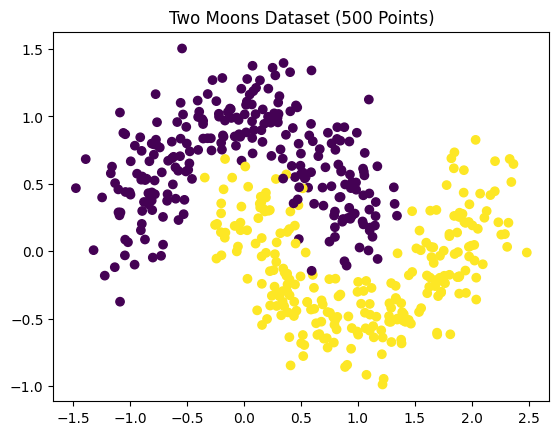

In [5]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Two Moons Dataset (500 Points)")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

           0       0.78      0.93      0.85        43
           1       0.94      0.81      0.87        57

    accuracy                           0.86       100
   macro avg       0.86      0.87      0.86       100
weighted avg       0.87      0.86      0.86       100

[[40  3]
 [11 46]]


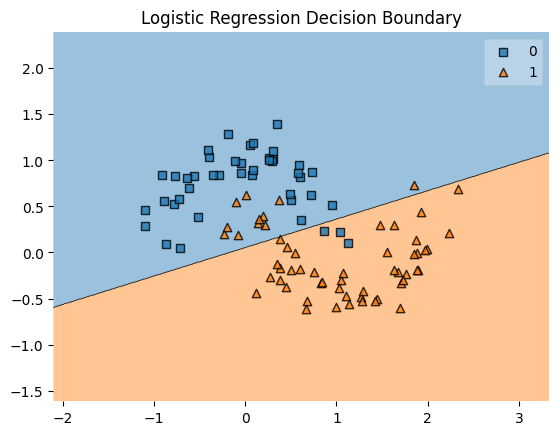

In [9]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
plot_decision_regions(X_test, y_test, clf=lr)
plt.title("Logistic Regression Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        43
           1       1.00      0.91      0.95        57

    accuracy                           0.95       100
   macro avg       0.95      0.96      0.95       100
weighted avg       0.96      0.95      0.95       100

[[43  0]
 [ 5 52]]


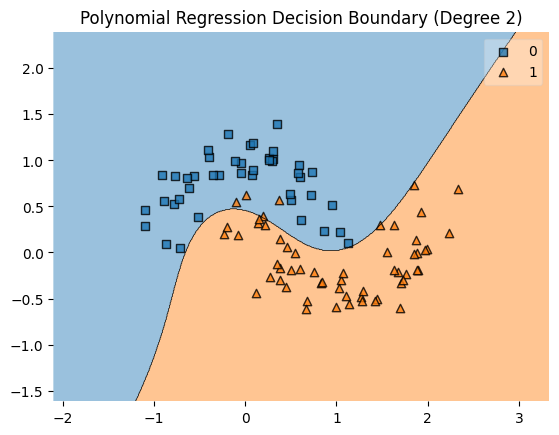

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LogisticRegression()
lr_poly.fit(X_train_poly, y_train)
lr_poly_pred = lr_poly.predict(X_test_poly)

print(classification_report(y_test, lr_poly_pred))
print(confusion_matrix(y_test, lr_poly_pred))

# Create a wrapper to transform data during plotting
class PolyWrapper:
    def __init__(self, model, poly_transformer):
        self.model = model
        self.poly = poly_transformer
    def predict(self, X):
        return self.model.predict(self.poly.transform(X))

plot_decision_regions(X_test, y_test, clf=PolyWrapper(lr_poly, poly))
plt.title("Polynomial Regression Decision Boundary (Degree 2)")
plt.show()

Polynomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.85        43
           1       0.96      0.77      0.85        57

    accuracy                           0.85       100
   macro avg       0.86      0.86      0.85       100
weighted avg       0.87      0.85      0.85       100

Confusion Matrix:
[[41  2]
 [13 44]]


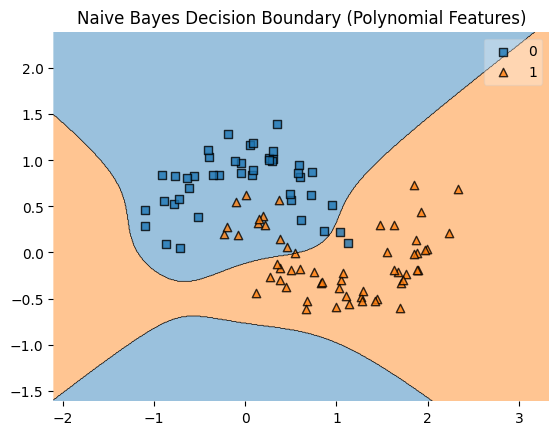

In [21]:
from sklearn.naive_bayes import GaussianNB
nb_poly = GaussianNB()
nb_poly.fit(X_train_poly, y_train)
nb_poly_pred = nb_poly.predict(X_test_poly)
print("Polynomial Naive Bayes Classification Report:")
print(classification_report(y_test, nb_poly_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_poly_pred))
plot_decision_regions(X_test, y_test, clf=PolyWrapper(nb_poly, poly))
plt.title("Naive Bayes Decision Boundary (Polynomial Features)")
plt.show()

              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.93      0.96        57

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

[[43  0]
 [ 4 53]]


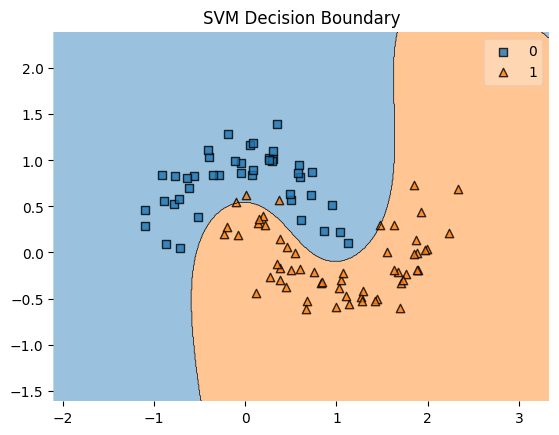

In [18]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))
plot_decision_regions(X_test, y_test, clf=svm)
plt.title("SVM Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.93      0.96        57

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

[[43  0]
 [ 4 53]]


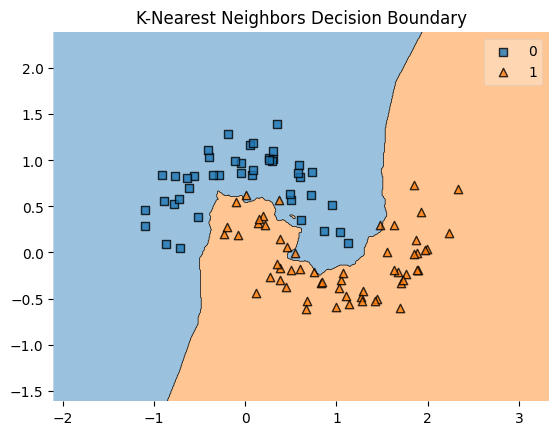

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
plot_decision_regions(X_test, y_test, clf=knn)
plt.title("K-Nearest Neighbors Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.93      0.96        57

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

[[43  0]
 [ 4 53]]


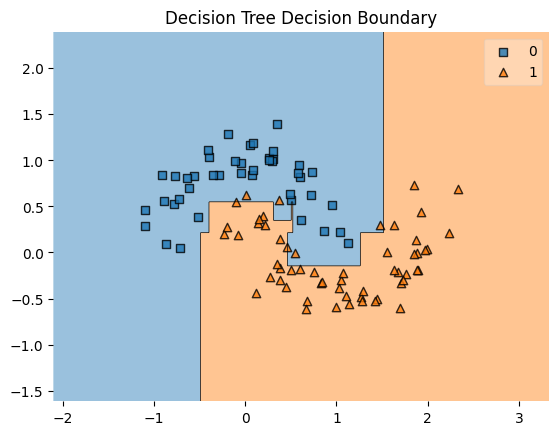

In [23]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
plot_decision_regions(X_test, y_test, clf=dt)
plt.title("Decision Tree Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

[[43  0]
 [ 3 54]]


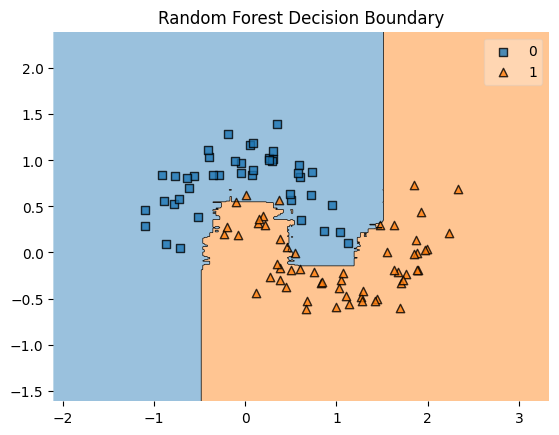

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
plot_decision_regions(X_test, y_test, clf=rf)
plt.title("Random Forest Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

[[43  0]
 [ 3 54]]


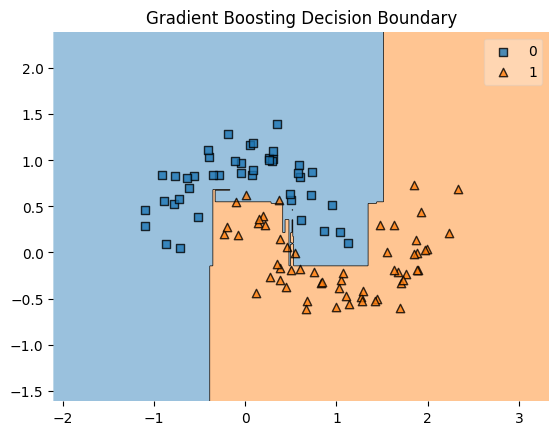

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print(classification_report(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))
plot_decision_regions(X_test, y_test, clf=gb)
plt.title("Gradient Boosting Decision Boundary")
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [05:08:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

[[43  0]
 [ 3 54]]


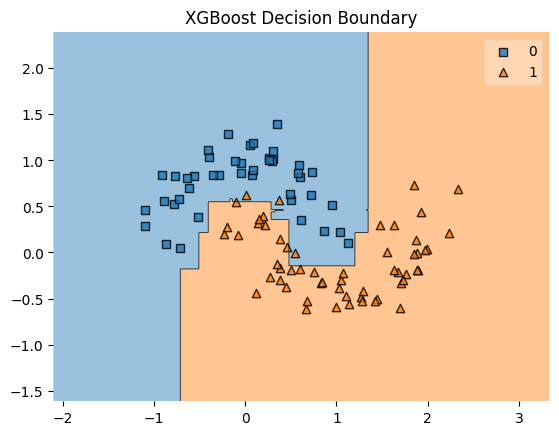

In [31]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
plot_decision_regions(X_test, y_test, clf=xgb_model)
plt.title("XGBoost Decision Boundary")
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        43
           1       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

[[43  0]
 [ 3 54]]


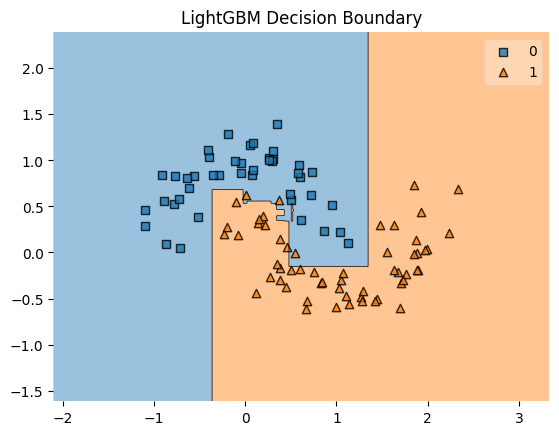

In [33]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
print(classification_report(y_test, lgbm_pred))
print(confusion_matrix(y_test, lgbm_pred))
plot_decision_regions(X_test, y_test, clf=lgbm)
plt.title("LightGBM Decision Boundary")
plt.show()

              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.93      0.96        57

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

[[43  0]
 [ 4 53]]


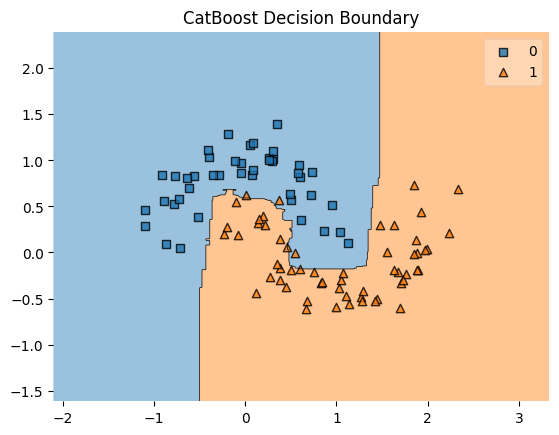

In [35]:
from catboost import CatBoostClassifier
cb = CatBoostClassifier(verbose=0)
cb.fit(X_train, y_train)
cb_pred = cb.predict(X_test)
print(classification_report(y_test, cb_pred))
print(confusion_matrix(y_test, cb_pred))
plot_decision_regions(X_test, y_test, clf=cb)
plt.title("CatBoost Decision Boundary")
plt.show()